# Modelo CNN 

## Activar GPU NVIDIA 

In [1]:
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
import torch

print(torch.__version__)               # Debe contener "cu121" o similar, NO "cpu"
print(torch.cuda.is_available())       # Debe imprimir: True
print(torch.cuda.get_device_name(0))   # Debe imprimir el nombre de tu GPU, ej: "NVIDIA GeForce RTX 3060"
device = (
    "cuda"  if torch.cuda.is_available() else
    "mps"   if torch.backends.mps.is_available() else  # Apple Silicon
    "cpu"
)
print(f"Usando dispositivo: {device}")
# Output esperado en tu caso → "Usando dispositivo: cuda"

2.5.1
True
NVIDIA GeForce RTX 4070 Laptop GPU
Usando dispositivo: cuda


## 1. Imports y configuración global

In [2]:
# --- Librerías estándar ---
import os
import pathlib

# --- Data Science ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- PyTorch core ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- Torchvision (imágenes) ---
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.utils import make_grid

# --- Scikit-learn (split y métricas) ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- PIL ---
from PIL import Image

# ============================================================
# CONSTANTES GLOBALES
# ============================================================

# Rutas
DATA_CSV  = pathlib.Path("../data/listingV5_PriceCapID.csv")
IMG_DIR   = pathlib.Path("../data/Front_Images/")
SYNC_CSV  = pathlib.Path("../data/listingV5_CNN.csv")       # CSV sincronizado (output Sección 1)
MODEL_DIR = pathlib.Path("models/")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparámetros de imagen
IMG_SIZE    = 224          # Estándar ImageNet (224x224 px)
BATCH_SIZE  = 32
NUM_EPOCHS  = 30
LR          = 1e-3
RANDOM_SEED = 42

# Estadísticas de normalización ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Dispositivo de cómputo: GPU si disponible, si no CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Eliminar el límite de tamaño de PIL para imágenes grandes de Airbnb
Image.MAX_IMAGE_PIXELS = None  # Suprimir DecompressionBombWarning

# ============================================================
# REPRODUCIBILIDAD
# ============================================================
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ============================================================
# DIAGNÓSTICO DE ENTORNO
# ============================================================
print("=" * 55)
print("  SmartHost Analytics — Fase 3: CNN Visual")
print("=" * 55)
print(f"  PyTorch versión : {torch.__version__}")
print(f"  Dispositivo     : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU             : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  ⚠️  Sin GPU — el entrenamiento será más lento en CPU.")
print(f"  IMG_SIZE        : {IMG_SIZE}x{IMG_SIZE} px")
print(f"  BATCH_SIZE      : {BATCH_SIZE}")
print(f"  NUM_EPOCHS      : {NUM_EPOCHS}")
print(f"  Learning Rate   : {LR}")
print("=" * 55)

  SmartHost Analytics — Fase 3: CNN Visual
  PyTorch versión : 2.5.1
  Dispositivo     : cuda
  GPU             : NVIDIA GeForce RTX 4070 Laptop GPU
  VRAM disponible : 8.6 GB
  IMG_SIZE        : 224x224 px
  BATCH_SIZE      : 32
  NUM_EPOCHS      : 30
  Learning Rate   : 0.001


## 1.1. Sincronización Dataset

In [3]:
# ============================================================
# CELDA 1.1 — CARGA DEL CSV LIMPIO
# ============================================================

df = pd.read_csv(DATA_CSV)

print(f"✅ CSV cargado: {len(df)} filas, {len(df.columns)} columnas")
print(f"   Columnas presentes: {list(df.columns[:8])} ...")

# Extraer solo los IDs (deben ser enteros)
ids_csv = set(df["id"].astype(int).tolist())
print(f"\n📋 IDs únicos en el CSV: {len(ids_csv)}")
df.head(3)

✅ CSV cargado: 5739 filas, 32 columnas
   Columnas presentes: ['id', 'host_response_time', 'host_response_rate', 'host_is_superhost', 'longitude', 'room_type', 'accommodates', 'bathrooms'] ...

📋 IDs únicos en el CSV: 5739


,id,host_response_time,host_response_rate,host_is_superhost,longitude,room_type,accommodates,bathrooms,bedrooms,beds,...,has_washer,has_heating,has_freezer,has_coffee_maker,has_balcony_or_terrace,distancia_centro_km,personas_por_habitacion,banos_por_huesped,amenities_score,distancia_playa_km
0,96033,within an hour,1.00,1.0,-4.356270,Entire home/apt,3,1.0,2.0,2.0,...,1,1,1,1,0,5.80,1.0,0.33,13,0.41
1,166473,within a day,1.00,1.0,-4.361080,Private room,1,2.0,1.0,4.0,...,1,1,0,0,1,5.37,0.5,2.00,10,0.35
2,330760,within an hour,0.91,0.0,-4.413462,Private room,2,1.5,1.0,1.0,...,1,1,1,1,0,1.18,1.0,0.75,14,1.34


In [4]:
# ============================================================
# CELDA 1.2 — INVENTARIO DE IMÁGENES EN DISCO
# ============================================================

# Obtener todos los archivos .jpg en la carpeta de imágenes
image_files = list(IMG_DIR.glob("*.jpg")) + list(IMG_DIR.glob("*.jpeg"))

# Construir set de IDs disponibles (nombre del archivo sin extensión)
ids_disponibles = set()
for f in image_files:
    try:
        ids_disponibles.add(int(f.stem))
    except ValueError:
        pass  # Ignorar archivos con nombre no numérico

print(f"🖼️  Imágenes encontradas en disco: {len(image_files)}")
print(f"🗂️  IDs de imágenes disponibles  : {len(ids_disponibles)}")

🖼️  Imágenes encontradas en disco: 8103
🗂️  IDs de imágenes disponibles  : 8103


  RESUMEN DE SINCRONIZACIÓN
  Filas en CSV original      : 5,739
  Imágenes disponibles       : 8,103
  Filas ELIMINADAS (sin img) : 72  (1.3%)
  ✅ Filas SINCRONIZADAS     : 5,667


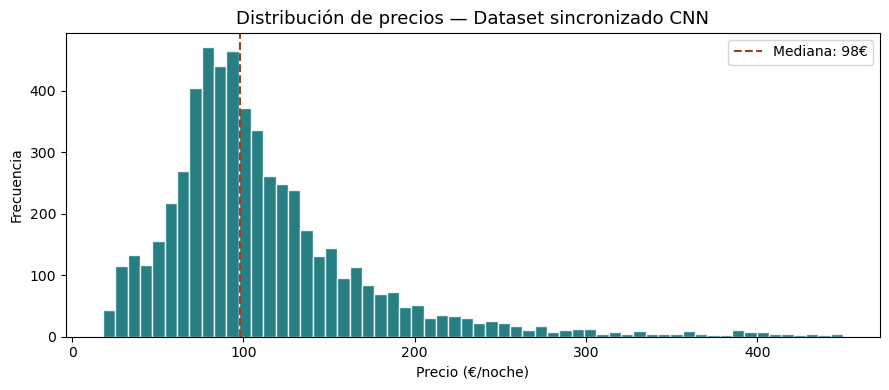


📊 Estadísticas de precio (post-filtro):
count    5667.00
mean      111.77
std        61.67
min        18.00
25%        75.00
50%        98.00
75%       132.00
max       450.00
Name: price, dtype: float64


In [5]:
# ============================================================
# CELDA 1.3 — FILTRO DE EMPAREJAMIENTO CSV ↔ IMÁGENES
# ============================================================

n_antes = len(df)

# IDs que existen en CSV Y en disco
ids_validos = ids_csv.intersection(ids_disponibles)

# Filtrar el DataFrame
df_sync = df[df["id"].astype(int).isin(ids_validos)].reset_index(drop=True)

n_despues = len(df_sync)
n_eliminados = n_antes - n_despues

print("=" * 50)
print("  RESUMEN DE SINCRONIZACIÓN")
print("=" * 50)
print(f"  Filas en CSV original      : {n_antes:,}")
print(f"  Imágenes disponibles       : {len(ids_disponibles):,}")
print(f"  Filas ELIMINADAS (sin img) : {n_eliminados:,}  ({n_eliminados/n_antes*100:.1f}%)")
print(f"  ✅ Filas SINCRONIZADAS     : {n_despues:,}")
print("=" * 50)

# Visualización de la distribución de precio tras el filtro
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_sync["price"], bins=60, color="#01696f", edgecolor="white", alpha=0.85)
ax.set_title("Distribución de precios — Dataset sincronizado CNN", fontsize=13)
ax.set_xlabel("Precio (€/noche)")
ax.set_ylabel("Frecuencia")
ax.axvline(df_sync["price"].median(), color="#964219", linestyle="--",
            label=f'Mediana: {df_sync["price"].median():.0f}€')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas de precio (post-filtro):")
print(df_sync["price"].describe().round(2))

In [6]:
# ============================================================
# CELDA 1.4 — GUARDAR EL CSV SINCRONIZADO
# ============================================================

df_sync.to_csv(SYNC_CSV, index=False)

print(f"CSV sincronizado guardado en: {SYNC_CSV}")
print(f"   Filas: {len(df_sync):,} | Columnas: {len(df_sync.columns)}")
print(f"\n   Este CSV es la ÚNICA fuente de verdad para el DataLoader.")
print(f"   Cada fila tiene su imagen .jpg correspondiente en {IMG_DIR}")

CSV sincronizado guardado en: ..\data\listingV5_CNN.csv
   Filas: 5,667 | Columnas: 32

   Este CSV es la ÚNICA fuente de verdad para el DataLoader.
   Cada fila tiene su imagen .jpg correspondiente en ..\data\Front_Images


## 2. DataLoader Visual

In [7]:
# ============================================================
# CELDA 2.1 — DATASET PERSONALIZADO (AirbnbImageDataset)
# ============================================================

class AirbnbImageDataset(Dataset):

    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = pathlib.Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img_id = int(row["id"])
        precio = float(row["price"])

        # Buscar el archivo (.jpg o .jpeg)
        img_path = self.img_dir / f"{img_id}.jpg"
        if not img_path.exists():
            img_path = self.img_dir / f"{img_id}.jpeg"

        # Cargar imagen — PIL.LOAD_TRUNCATED_IMAGES evita crashes
        # en imágenes parcialmente corruptas o descargadas a medias
        from PIL import ImageFile
        ImageFile.LOAD_TRUNCATED_IMAGES = True

        img = Image.open(img_path).convert("RGB")

        # ── MINIATURA ANTES DE TRANSFORMAR ──────────────────
        # Si la imagen es gigante (>2000px), reducirla a 512px
        # ANTES de aplicar el pipeline. Esto evita cargar
        # 100M de píxeles en RAM para luego recortarlos a 224px.
        # Image.thumbnail es in-place y NO degrada calidad para 224px.
        if max(img.size) > 2000:
            img.thumbnail((512, 512), Image.LANCZOS)

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(precio, dtype=torch.float32)


print("✅ Clase AirbnbImageDataset definida.")
print(f"   Cada __getitem__ devuelve: (Tensor [3, {IMG_SIZE}, {IMG_SIZE}], precio_float)")

✅ Clase AirbnbImageDataset definida.
   Cada __getitem__ devuelve: (Tensor [3, 224, 224], precio_float)


In [8]:
# ============================================================
# CELDA 2.2 — PIPELINES DE TRANSFORMACIÓN
# ============================================================
#
# ┌─────────────────────────────────────────────────────────┐
# │  PIPELINE TRAIN                │  PIPELINE VAL/TEST     │
# │  ─────────────────────────────── ────────────────────── │
# │  1. Resize(256)                │  1. Resize(256)         │
# │  2. CenterCrop(224)            │  2. CenterCrop(224)     │
# │  3. RandomHorizontalFlip()     │  3. (sin augmentation)  │
# │  4. ToTensor()                 │  4. ToTensor()          │
# │  5. Normalize(ImageNet)        │  5. Normalize(ImageNet) │
# └─────────────────────────────────────────────────────────┘
# ✦ Solo en train: simula que el sofá puede estar a izquierda
#   o derecha — evita que el modelo memorice orientaciones.

transform_train = transforms.Compose([
    transforms.Resize(256),                          # Escalar al tamaño intermedio
    transforms.CenterCrop(IMG_SIZE),                 # Recortar el centro exacto: 224x224
    transforms.RandomHorizontalFlip(p=0.5),          # Data Augmentation (solo train)
    transforms.ToTensor(),                           # [H,W,C] uint8 → [C,H,W] float [0,1]
    transforms.Normalize(                            # Normalizar con stats de ImageNet
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])

transform_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    # ← SIN RandomHorizontalFlip: validación siempre determinista
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("✅ Pipelines de transformación definidos.")
print("\n  transform_train:")
for i, t in enumerate(transform_train.transforms):
    marker = " ✦ (solo train)" if "Flip" in type(t).__name__ else ""
    print(f"    {i+1}. {type(t).__name__}{marker}")
print("\n  transform_val:")
for i, t in enumerate(transform_val.transforms):
    print(f"    {i+1}. {type(t).__name__}")

✅ Pipelines de transformación definidos.

  transform_train:
    1. Resize
    2. CenterCrop
    3. RandomHorizontalFlip ✦ (solo train)
    4. ToTensor
    5. Normalize

  transform_val:
    1. Resize
    2. CenterCrop
    3. ToTensor
    4. Normalize


In [9]:
# ============================================================
# CELDA 2.3 — SPLIT TRAIN/VAL Y DATALOADERS
# ============================================================

# Leer el CSV sincronizado generado en la Sección 1
df_sync = pd.read_csv(SYNC_CSV)

# --- Split 80% Train / 20% Val (stratify no aplica en regresión) ---
df_train, df_val = train_test_split(
    df_sync,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# --- Instanciar datasets con su transform correspondiente ---
dataset_train = AirbnbImageDataset(df_train, IMG_DIR, transform=transform_train)
dataset_val   = AirbnbImageDataset(df_val,   IMG_DIR, transform=transform_val)

# --- DataLoaders ---
# num_workers=4: carga en paralelo (ajustar a 0 si da errores en Windows)
loader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,           # Barajar en cada epoch (solo train)
    num_workers=0,
    pin_memory=True         # Acelera la transferencia CPU→GPU
)

loader_val = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,          # Validación: orden fijo, resultados reproducibles
    num_workers=0,
    pin_memory=True
)

print("=" * 50)
print("  RESUMEN DE SPLITS Y DATALOADERS")
print("=" * 50)
print(f"  Total apartamentos sync : {len(df_sync):,}")
print(f"  Train                   : {len(dataset_train):,} imágenes ({len(loader_train)} batches)")
print(f"  Val                     : {len(dataset_val):,} imágenes ({len(loader_val)} batches)")
print(f"  Batch size              : {BATCH_SIZE}")
print(f"  pin_memory              : True (GPU activa)")
print("=" * 50)

  RESUMEN DE SPLITS Y DATALOADERS
  Total apartamentos sync : 5,667
  Train                   : 4,533 imágenes (142 batches)
  Val                     : 1,134 imágenes (36 batches)
  Batch size              : 32
  pin_memory              : True (GPU activa)


📐 Shape del batch : torch.Size([32, 3, 224, 224])  → [batch, canales, alto, ancho]
💰 Precios del batch (primeros 8): [154.  61. 102.  98.  60.  25.  64.  78.] €/noche
   min=25€  |  max=305€  |  media=106€


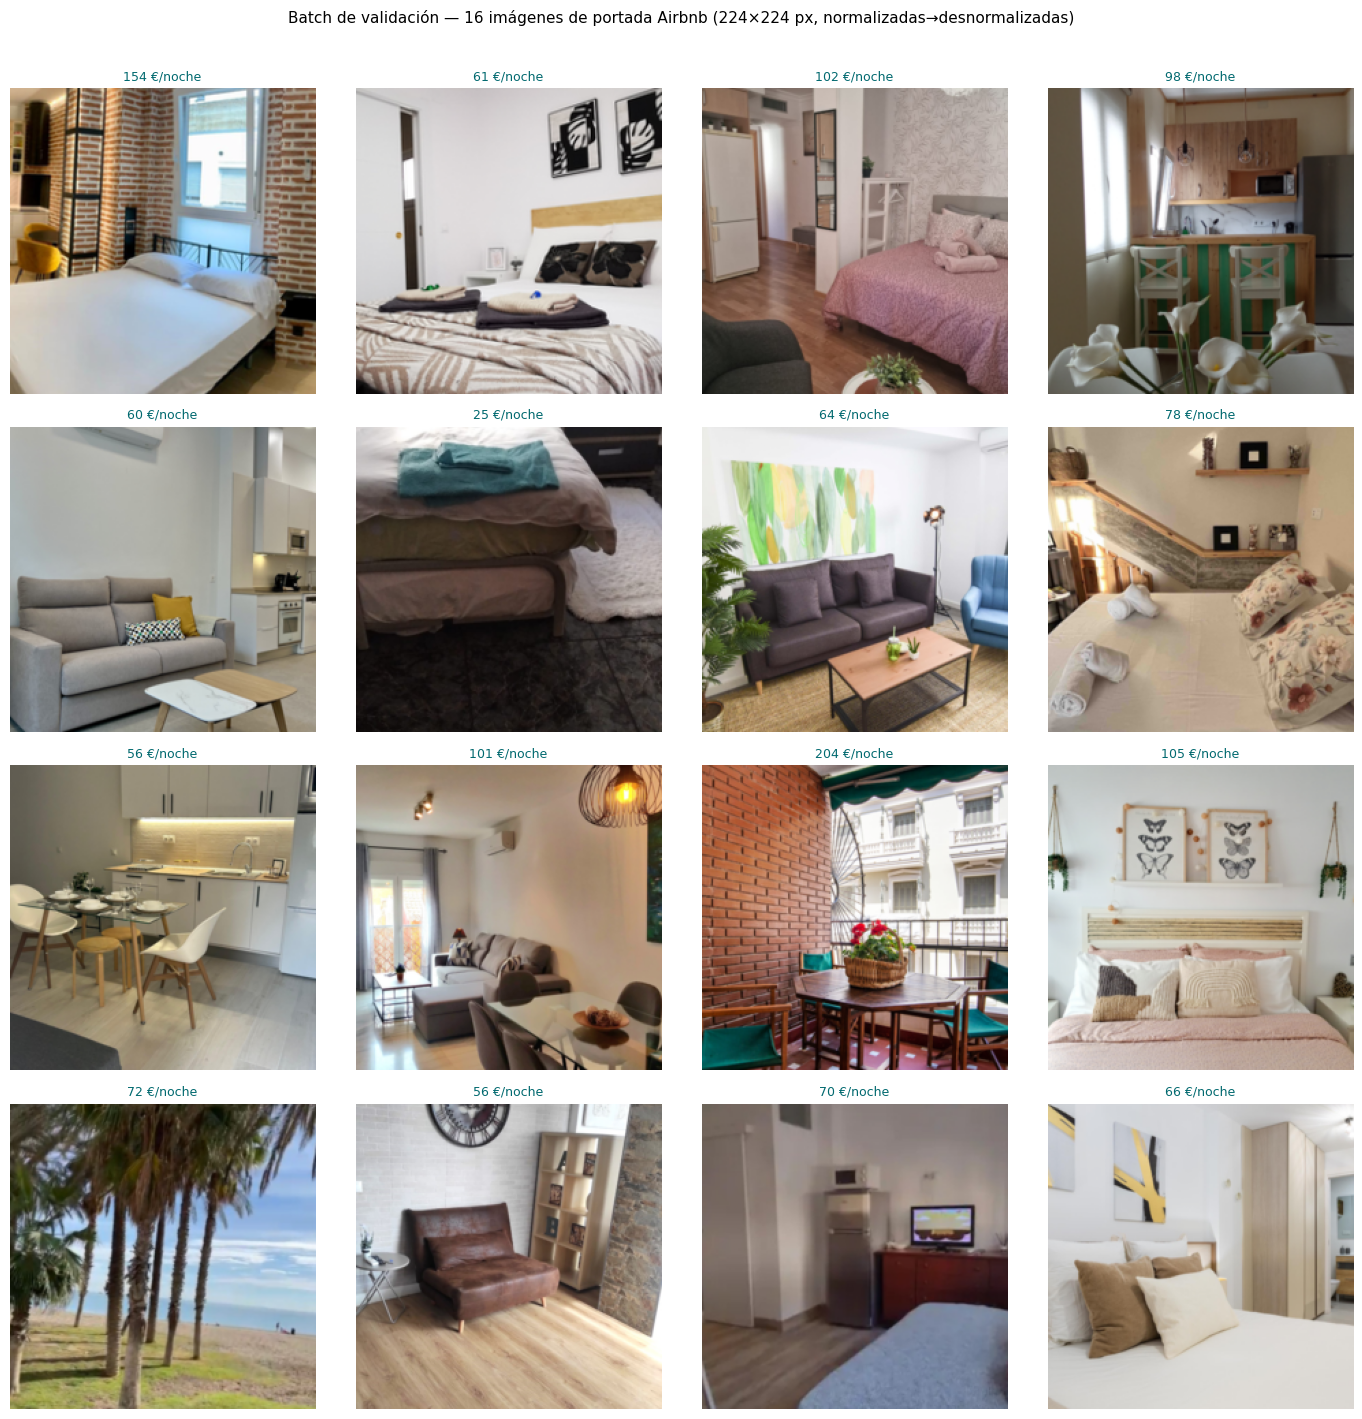


✅ Sección 2 completada. DataLoaders listos para el entrenamiento.
   → Siguiente paso: Sección 3 — Arquitectura Transfer Learning (MobileNetV2)


In [10]:
# ============================================================
# CELDA 2.4 — VERIFICACIÓN VISUAL DEL BATCH
# ============================================================
# Desnormalizar para poder visualizar: inv(Normalize) = x*std + mean

def desnormalizar(tensor):
    """Invierte la normalización ImageNet para visualizar la imagen."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Extraer un batch de validación (sin augmentation → más representativo)
imagenes, precios = next(iter(loader_val))

print(f"📐 Shape del batch : {imagenes.shape}  → [batch, canales, alto, ancho]")
print(f"💰 Precios del batch (primeros 8): {precios[:8].numpy().round(0)} €/noche")
print(f"   min={precios.min():.0f}€  |  max={precios.max():.0f}€  |  media={precios.mean():.0f}€")

# --- Visualizar cuadrícula 4x4 ---
n_mostrar = min(16, len(imagenes))
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle(
    f"Batch de validación — {n_mostrar} imágenes de portada Airbnb (224×224 px, normalizadas→desnormalizadas)",
    fontsize=11, y=1.01
)

for i, ax in enumerate(axes.flat):
    if i < n_mostrar:
        img_vis = desnormalizar(imagenes[i]).permute(1, 2, 0).numpy()
        ax.imshow(img_vis)
        ax.set_title(f"{precios[i]:.0f} €/noche", fontsize=9, color="#01696f")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("\n✅ Sección 2 completada. DataLoaders listos para el entrenamiento.")
print("   → Siguiente paso: Sección 3 — Arquitectura Transfer Learning (MobileNetV2)")

## 3. Arquitectura: Transfer Learning

In [11]:
# ============================================================
# CELDA 3.1 — CARGAR MobileNetV2 PRE-ENTRENADO EN ImageNet
# ============================================================

# Cargar MobileNetV2 con pesos oficiales de ImageNet
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Inspeccionar la arquitectura completa
print("=" * 60)
print("  ARQUITECTURA MobileNetV2 ORIGINAL")
print("=" * 60)
print(model)
print("\n")

# Localizar la cabeza clasificadora original
print("=" * 60)
print("  CABEZA ORIGINAL (model.classifier):")
print("=" * 60)
print(model.classifier)
print(f"\n  → Entrada : 1280 características (salida del backbone)")
print(f"  → Salida  : 1000 clases (ImageNet: perro, gato, coche...)")
#Esta cabeza NO sirve para nuestro problema de regresión.
#La cortaremos y sustituiremos por nuestra propia capa

  ARQUITECTURA MobileNetV2 ORIGINAL
MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)

In [12]:
# ============================================================
# CELDA 3.2 — CONGELACIÓN (FREEZING) DEL BACKBONE
# ============================================================

# Mobile NetV2 se compone de:
#Capas convolucionales ya entrenadas, sabiendo detectar: bordes, texturas, formas, objetos...
# Quitaremos la última capa (classifier) y la reemplazaremos por una nueva capa lineal adaptada a nuestro problema
# De manera que escupa un sólo número (precio) en lugar de 1000 clases.

# Congelar TODAS las capas del backbone
for param in model.parameters():
    param.requires_grad = False

print("❄️  Backbone congelado — conocimiento visual de ImageNet preservado.")
print("   Ninguna capa del backbone se actualizará durante el entrenamiento.")

❄️  Backbone congelado — conocimiento visual de ImageNet preservado.
   Ninguna capa del backbone se actualizará durante el entrenamiento.


In [13]:
# ============================================================
# CELDA 3.3 — SUSTITUCIÓN DE LA CABEZA (HEAD)
# ============================================================

# La cabeza original de MobileNetV2 es:
#   Sequential(Dropout(0.2), Linear(1280, 1000))
#
# La sustituimos por nuestra cabeza de regresión:
#   Sequential(Dropout(0.2), Linear(1280, 1))
# 1 solo número = el precio €/noche

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),          # Regularización: apaga el 20% de neuronas al azar
    nn.Linear(1280, 1)          # 1280 features → 1 precio (sin activación = regresión lineal)
)

# Mover el modelo completo a GPU (o CPU si no hay GPU)
model = model.to(DEVICE)

print("✅ Cabeza sustituida correctamente.")
print(f"\n  Nueva model.classifier:")
print(f"  {model.classifier}")
print(f"\n  Entrada  : 1280 características visuales (backbone frozen)")
print(f"  Salida   : 1 número continuo → precio estimado en €/noche")
print(f"  Activación final: NINGUNA (regresión — salida libre en ℝ)")
print(f"\n  Modelo enviado a: {DEVICE}")

✅ Cabeza sustituida correctamente.

  Nueva model.classifier:
  Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)

  Entrada  : 1280 características visuales (backbone frozen)
  Salida   : 1 número continuo → precio estimado en €/noche
  Activación final: NINGUNA (regresión — salida libre en ℝ)

  Modelo enviado a: cuda


In [14]:
# ============================================================
# CELDA 3.4 — VERIFICAR PARÁMETROS ENTRENABLES
# ============================================================

total_params      = sum(p.numel() for p in model.parameters())
entrenables       = sum(p.numel() for p in model.parameters() if p.requires_grad)
congelados        = total_params - entrenables
pct_entrenables   = entrenables / total_params * 100

print("=" * 55)
print("  PARÁMETROS DEL MODELO")
print("=" * 55)
print(f"  Total parámetros       : {total_params:>12,}")
print(f"  ❄️  Congelados (frozen) : {congelados:>12,}  ({100 - pct_entrenables:.2f}%)")
print(f"  🔥 Entrenables         : {entrenables:>12,}  ({pct_entrenables:.2f}%)")
print("=" * 55)
print(f"\n  ✅ Solo se entrena el {pct_entrenables:.2f}% del modelo.")
print(f"     Esto es Transfer Learning: aprovechamos el 99%+ del")
print(f"     conocimiento visual aprendido de 1.2M imágenes de ImageNet")
print(f"     y solo ajustamos la capa final a nuestro problema.")

# Verificación explícita: listar qué capas tienen gradiente activo
print(f"\n  Capas con requires_grad=True (entrenables):")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"    ✓ {name:40s} → shape: {list(param.shape)}")

  PARÁMETROS DEL MODELO
  Total parámetros       :    2,225,153
  ❄️  Congelados (frozen) :    2,223,872  (99.94%)
  🔥 Entrenables         :        1,281  (0.06%)

  ✅ Solo se entrena el 0.06% del modelo.
     Esto es Transfer Learning: aprovechamos el 99%+ del
     conocimiento visual aprendido de 1.2M imágenes de ImageNet
     y solo ajustamos la capa final a nuestro problema.

  Capas con requires_grad=True (entrenables):
    ✓ classifier.1.weight                      → shape: [1, 1280]
    ✓ classifier.1.bias                        → shape: [1]


## 4. Entrenamiento del modelo CNN

In [15]:
# ============================================================
# CELDA 4.1 — FUNCIÓN DE PÉRDIDA, OPTIMIZADOR Y SCHEDULER
# ============================================================

# --- Función de pérdida ---
# MAELoss (L1) es más robusta a outliers de precio que MSELoss (L2)
# y da el error directamente en €/noche → más interpretable
criterion = nn.L1Loss()

# --- Optimizador ---
# Solo pasamos los parámetros con requires_grad=True (nuestra nueva cabeza)
# El backbone congelado NO recibe gradientes → no se actualizará
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

# --- Learning Rate Scheduler ---
# ReduceLROnPlateau: si val_loss no mejora en 'patience' epochs,
# divide el LR por 'factor'. Evita que el modelo se estanque.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # Minimizar val_loss
    factor=0.5,       # Nuevo LR = LR * 0.5
    patience=4,       # Esperar 4 epochs sin mejora antes de reducir
    verbose=True      # Imprimir cuando cambie el LR
)

print("✅ Criterio, optimizador y scheduler configurados.")
print(f"\n  Función de pérdida : L1Loss (MAE — error en €/noche)")
print(f"  Optimizador        : Adam (lr={LR})")
print(f"  Scheduler          : ReduceLROnPlateau (patience=4, factor=0.5)")
print(f"\n  Parámetros que se optimizan:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"    🔥 {name:40s} → {list(param.shape)}")

✅ Criterio, optimizador y scheduler configurados.

  Función de pérdida : L1Loss (MAE — error en €/noche)
  Optimizador        : Adam (lr=0.001)
  Scheduler          : ReduceLROnPlateau (patience=4, factor=0.5)

  Parámetros que se optimizan:
    🔥 classifier.1.weight                      → [1, 1280]
    🔥 classifier.1.bias                        → [1]


c:\Users\david\anaconda3\envs\Airbnb_PIA\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [16]:
# ============================================================
# CELDA 4.2 — BUCLE DE ENTRENAMIENTO CON EARLY STOPPING
# ============================================================
from tqdm import tqdm

# --- Configuración Early Stopping ---
EARLY_STOPPING_PATIENCE = 8
best_val_loss            = float("inf")
epochs_sin_mejora        = 0
best_model_weights       = None

# --- Historial ---
historial = {
    "epoch":      [],
    "train_mae":  [],
    "train_mse":  [],
    "val_mae":    [],
    "val_mse":    [],
    "val_rmse":   [],
    "val_r2":     [],
    "lr":         []
}

print("🚀 Iniciando entrenamiento...\n")
print(f"{'Ep':>4} | {'Tr.MSE':>8} | {'Tr.MAE':>8} | {'Va.MSE':>8} | {'Va.MAE':>8} | {'Va.RMSE':>8} | {'R²':>6} | {'LR':>8} | Estado")
print("-" * 105)

for epoch in range(1, NUM_EPOCHS + 1):

    # ── FASE TRAIN ───────────────────────────────────────────
    model.train()
    train_mae_acum = 0.0
    train_mse_acum = 0.0

    for imagenes, precios in tqdm(loader_train,
                                    desc=f"  Epoch {epoch:02d}/{NUM_EPOCHS} [TRAIN]",
                                    leave=False):    # leave=False → borra la barra al terminar
        imagenes = imagenes.to(DEVICE)
        precios  = precios.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        predicciones = model(imagenes)

        loss_mae = criterion(predicciones, precios)           # L1 (MAE)
        loss_mae.backward()
        optimizer.step()

        n = len(imagenes)
        train_mae_acum += loss_mae.item() * n
        train_mse_acum += ((predicciones - precios) ** 2).sum().item()

    n_train       = len(dataset_train)
    train_mae     = train_mae_acum / n_train
    train_mse     = train_mse_acum / n_train

    # ── FASE VALIDACIÓN ──────────────────────────────────────
    model.eval()
    val_preds_list  = []
    val_labels_list = []

    with torch.no_grad():
        for imagenes, precios in tqdm(loader_val,
                                        desc=f"  Epoch {epoch:02d}/{NUM_EPOCHS} [VAL]  ",
                                        leave=False):
            imagenes = imagenes.to(DEVICE)
            preds    = model(imagenes).squeeze(1).cpu()
            val_preds_list.append(preds)
            val_labels_list.append(precios)

    val_preds  = torch.cat(val_preds_list).numpy()
    val_labels = torch.cat(val_labels_list).numpy()

    val_mae  = mean_absolute_error(val_labels, val_preds)
    val_mse  = mean_squared_error(val_labels, val_preds)
    val_rmse = np.sqrt(val_mse)
    val_r2   = r2_score(val_labels, val_preds)

    # ── SCHEDULER ────────────────────────────────────────────
    scheduler.step(val_mae)
    lr_actual = optimizer.param_groups[0]["lr"]

    # ── EARLY STOPPING ───────────────────────────────────────
    if val_mae < best_val_loss:
        best_val_loss      = val_mae
        epochs_sin_mejora  = 0
        best_model_weights = {k: v.clone() for k, v in model.state_dict().items()}
        estado = "✅ Mejor"
    else:
        epochs_sin_mejora += 1
        estado = f"⏳ {epochs_sin_mejora}/{EARLY_STOPPING_PATIENCE}"

    # ── REGISTRO ─────────────────────────────────────────────
    historial["epoch"].append(epoch)
    historial["train_mae"].append(train_mae)
    historial["train_mse"].append(train_mse)
    historial["val_mae"].append(val_mae)
    historial["val_mse"].append(val_mse)
    historial["val_rmse"].append(val_rmse)
    historial["val_r2"].append(val_r2)
    historial["lr"].append(lr_actual)

    print(f"{epoch:>4} | {train_mse:>8.1f} | {train_mae:>7.2f}€ | "
            f"{val_mse:>8.1f} | {val_mae:>7.2f}€ | {val_rmse:>7.2f}€ | "
            f"{val_r2:>5.3f} | {lr_actual:>8.2e} | {estado}")

    if epochs_sin_mejora >= EARLY_STOPPING_PATIENCE:
        print(f"\n🛑 Early Stopping en epoch {epoch} — mejor Val MAE: {best_val_loss:.2f}€")
        break

model.load_state_dict(best_model_weights)
print(f"\n✅ Pesos del mejor modelo restaurados (Val MAE = {best_val_loss:.2f}€)")

🚀 Iniciando entrenamiento...

  Ep |   Tr.MSE |   Tr.MAE |   Va.MSE |   Va.MAE |  Va.RMSE |     R² |       LR | Estado
---------------------------------------------------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
# ============================================================
# CELDA 4.3 — CURVAS DE APRENDIZAJE
# ============================================================

df_hist = pd.DataFrame(historial)
epoch_mejor = df_hist["val_loss"].idxmin() + 1  # epoch (base-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas de Aprendizaje — CNN Visual (MobileNetV2)", fontsize=13)

# --- Gráfico 1: Train Loss vs Val Loss ---
ax1.plot(df_hist["epoch"], df_hist["train_loss"],
         label="Train MAE", color="#01696f", linewidth=2)
ax1.plot(df_hist["epoch"], df_hist["val_loss"],
         label="Val MAE",   color="#964219", linewidth=2)
ax1.axvline(epoch_mejor, color="#964219", linestyle="--", alpha=0.5,
            label=f"Mejor epoch ({epoch_mejor})")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MAE (€/noche)")
ax1.set_title("Error de entrenamiento vs validación")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Diagnóstico visual
gap = df_hist["train_loss"].iloc[-1] - df_hist["val_loss"].iloc[-1]
if abs(gap) < 5:
    diagnostico = "✅ Ajuste correcto (gap train/val pequeño)"
elif gap < -5:
    diagnostico = "⚠️ Posible underfitting (train > val)"
else:
    diagnostico = "⚠️ Posible overfitting (val >> train)"
ax1.set_xlabel(f"Epoch\n{diagnostico}")

# --- Gráfico 2: Evolución del Learning Rate ---
ax2.plot(df_hist["epoch"], df_hist["lr"],
         color="#7a39bb", linewidth=2, marker="o", markersize=3)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Learning Rate")
ax2.set_title("Evolución del Learning Rate (ReduceLROnPlateau)")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Resumen del entrenamiento:")
print(f"   Epochs ejecutados   : {len(df_hist)}")
print(f"   Mejor epoch         : {epoch_mejor}")
print(f"   Mejor Val MAE       : {best_val_loss:.2f} €/noche")

In [ ]:
# ============================================================
# CELDA 4.4 — EVALUACIÓN FINAL CON MÉTRICAS
# ============================================================

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for imagenes, precios in loader_val:
        imagenes = imagenes.to(DEVICE)
        preds    = model(imagenes).squeeze(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(precios.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Calcular métricas ---
mae  = mean_absolute_error(all_labels, all_preds)
rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
r2   = r2_score(all_labels, all_preds)

print("=" * 55)
print("  MÉTRICAS FINALES — SET DE VALIDACIÓN")
print("=" * 55)
print(f"  MAE  (Error Absoluto Medio) : {mae:.2f} €/noche")
print(f"  RMSE (Error Cuadrático)     : {rmse:.2f} €/noche")
print(f"  R²   (Coef. Determinación)  : {r2:.4f}  ({r2*100:.1f}%)")
print("=" * 55)

# --- Interpretación del R² ---
print("\n  📌 Interpretación del R²:")
if r2 >= 0.30:
    print(f"  🏆 R² = {r2*100:.1f}% → ¡ÉXITO ROTUNDO!")
    print(f"     La CNN ha aprendido a detectar estética visual.")
    print(f"     El vector de características está listo para la fusión.")
elif r2 >= 0.15:
    print(f"  ✅ R² = {r2*100:.1f}% → Resultado CORRECTO.")
    print(f"     La CNN extrae señal visual útil del precio.")
    print(f"     Recuerda: una foto sola no sabe si el piso está en el centro.")
elif r2 >= 0.0:
    print(f"  ⚠️  R² = {r2*100:.1f}% → Señal visual débil pero positiva.")
    print(f"     Considera aumentar NUM_EPOCHS o descongelar algunas capas.")
else:
    print(f"  ❌ R² = {r2*100:.1f}% → El modelo no ha aprendido.")
    print(f"     Revisar dataset (¿imágenes corruptas?) o reducir LR.")

# --- Scatter: Predicho vs Real ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(all_labels, all_preds, alpha=0.3, s=12, color="#01696f")
lims = [min(all_labels.min(), all_preds.min()),
        max(all_labels.max(), all_preds.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
ax.set_xlabel("Precio real (€/noche)")
ax.set_ylabel("Precio predicho (€/noche)")
ax.set_title(f"Predicho vs Real — R²={r2*100:.1f}%  |  MAE={mae:.1f}€")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Guardado del modelo y preparación para la fusión multimodal

In [ ]:
# ============================================================
# CELDA 5.1 — GUARDAR LOS PESOS DEL MODELO (cnn_model.pt)
# ============================================================

ruta_modelo = MODEL_DIR / "cnn_model.pt"

torch.save(model.state_dict(), ruta_modelo)

print("=" * 55)
print("  MODELO GUARDADO")
print("=" * 55)
print(f"  📁 Ruta : {ruta_modelo}")
print(f"  📦 Tamaño : {ruta_modelo.stat().st_size / 1e6:.1f} MB")
print(f"\n  Contenido guardado: state_dict()")
print(f"  → Todos los pesos del backbone (frozen)")
print(f"  → Los pesos entrenados de model.classifier")
print(f"\n  Para recargar el modelo completo en el futuro:")
print(f"    model = models.mobilenet_v2()")
print(f"    model.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(1280, 1))")
print(f"    model.load_state_dict(torch.load('models/cnn_model.pt'))")

In [ ]:
# ============================================================
# CELDA 5.2 — CREAR EL FEATURE EXTRACTOR VISUAL
# ============================================================


# Construir el extractor: cargamos los pesos guardados y
# reemplazamos la cabeza por Identity (pasa el tensor sin tocarlo)
feature_extractor = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
)
feature_extractor.classifier = nn.Identity()  # Eliminar cabeza → salida = 1280 features

# Cargar los pesos entrenados del backbone (la cabeza Identity no tiene pesos)
state_dict_entrenado = torch.load(ruta_modelo, map_location=DEVICE)

# Filtrar solo los pesos del backbone (excluir classifier.*)
state_dict_backbone = {
    k: v for k, v in state_dict_entrenado.items()
    if not k.startswith("classifier")
}
feature_extractor.load_state_dict(state_dict_backbone, strict=False)

feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()  # Siempre en modo eval: no Dropout, no BatchNorm en train

print("✅ Feature Extractor construido correctamente.")
print(f"\n  Backbone     : MobileNetV2 (pesos del entrenamiento CNN cargados)")
print(f"  Cabeza       : nn.Identity() — eliminada")
print(f"  Modo         : eval() — determinista, sin dropout activo")
print(f"  Dispositivo  : {DEVICE}")

In [ ]:
# ============================================================
# CELDA 5.3 — TEST DEL FEATURE EXTRACTOR
# ============================================================

# Extraer un batch del loader de validación para probar
imagenes_test, precios_test = next(iter(loader_val))
imagenes_test = imagenes_test.to(DEVICE)

with torch.no_grad():
    vector_features = feature_extractor(imagenes_test)

print("=" * 55)
print("  TEST DEL FEATURE EXTRACTOR")
print("=" * 55)
print(f"  Input  — batch de imágenes : {imagenes_test.shape}")
print(f"                                 [batch, 3, 224, 224]")
print(f"\n  Output — vector de features : {vector_features.shape}")
print(f"                                 [batch, 1280]")
print("=" * 55)

# Verificar que la forma es la esperada
assert vector_features.shape == (imagenes_test.shape[0], 1280), \
    f"❌ Shape inesperado: {vector_features.shape}"

print(f"\n  ✅ Shape verificado: cada imagen → vector de 1280 números")
print(f"\n  Estadísticas del vector (primer apartamento):")
v = vector_features[0].cpu().numpy()
print(f"    Min   : {v.min():.4f}")
print(f"    Max   : {v.max():.4f}")
print(f"    Media : {v.mean():.4f}")
print(f"    Std   : {v.std():.4f}")

# --- Visualizar los primeros 128 valores del vector del primer apt ---
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(128), v[:128], color="#01696f", alpha=0.7, width=1.0)
ax.set_title("Feature vector visual — primeros 128 de 1280 valores (apartamento #0 del batch)")
ax.set_xlabel("Índice de feature")
ax.set_ylabel("Activación")
ax.axhline(0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"\n{'=' * 55}")
print(f"  🎯 FASE 3 COMPLETADA")
print(f"{'=' * 55}")
print(f"  Archivos generados:")
print(f"    📁 models/cnn_model.pt       — pesos completos del modelo")
print(f"\n  En la FASE FINAL (Fusión Multimodal):")
print(f"    1. Cargar feature_extractor desde cnn_model.pt")
print(f"    2. Para cada apartamento: imagen → vector [1280]")
print(f"    3. Concatenar con vector tabular [N features]")
print(f"    4. Pasar por capa densa final → precio optimizado €")